练习数据来源:https://kaggle.com

In [45]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/medical-insurance-cost-prediction")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\www12\.cache\kagglehub\datasets\mohankrishnathalla\medical-insurance-cost-prediction\versions\1


In [46]:
import pandas as pd

# 加载数据的函数
def load_medical_data(path):
    return pd.read_csv(path)

medical = load_medical_data("./datasets/kaggle/mohankrishnathalla/medical_insurance.csv")

# 1. 快速浏览数据结构

In [47]:
medical.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [48]:
medical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

0. **person_id**：个体唯一标识符（ID，仅用于区分样本，不参与建模）
1. **age**：年龄（岁）
2. **sex**：性别
3. **region**：所在地区
4. **urban_rural**：居住环境类型（城市 / 农村）
5. **income**：个人或家庭年收入
6. **education**：教育水平
7. **marital_status**：婚姻状况
8. **employment_status**：就业状态
9. **household_size**：家庭人口规模
10. **dependents**：需抚养/赡养人数
11. **bmi**：身体质量指数
12. **smoker**：是否吸烟
13. **alcohol_freq**：饮酒频率
14. **visits_last_year**：过去一年医疗就诊次数
15. **hospitalizations_last_3yrs**：过去三年住院次数
16. **days_hospitalized_last_3yrs**：过去三年累计住院天数
17. **medication_count**：当前或近期使用的药物数量
18. **systolic_bp**：收缩压
19. **diastolic_bp**：舒张压
20. **ldl**：低密度脂蛋白胆固醇水平
21. **hba1c**：糖化血红蛋白水平
22. **plan_type**：保险计划类型
23. **network_tier**：医疗服务网络等级
24. **deductible**：免赔额
25. **copay**：单次医疗自付额
26. **policy_term_years**：保险合同年限
27. **policy_changes_last_2yrs**：近两年保单变更次数
28. **provider_quality**：医疗服务提供方质量评分
29. **risk_score**：综合健康/风险评分
30. **annual_medical_cost**：年度医疗总费用（回归预测目标之一）
31. **annual_premium**：年度保险保费
32. **monthly_premium**：月度保险保费
33. **claims_count**：理赔次数
34. **avg_claim_amount**：平均单次理赔金额
35. **total_claims_paid**：累计理赔支付金额
36. **chronic_count**：慢性疾病数量
37. **hypertension**：是否患有高血压
38. **diabetes**：是否患有糖尿病
39. **asthma**：是否患有哮喘
40. **copd**：是否患有慢性阻塞性肺疾病
41. **cardiovascular_disease**：是否患有心血管疾病
42. **cancer_history**：是否有癌症病史
43. **kidney_disease**：是否患有肾脏疾病
44. **liver_disease**：是否患有肝脏疾病
45. **arthritis**：是否患有关节炎
46. **mental_health**：是否存在心理健康问题
47. **proc_imaging_count**：影像学检查次数
48. **proc_surgery_count**：手术次数
49. **proc_physio_count**：物理治疗次数
50. **proc_consult_count**：门诊 / 会诊次数
51. **proc_lab_count**：实验室检查次数
52. **is_high_risk**：是否被判定为高风险个体（二分类标签）
53. **had_major_procedure**：是否经历过重大医疗手术（二分类标签）


In [49]:
medical.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


为每个属性绘制直方图

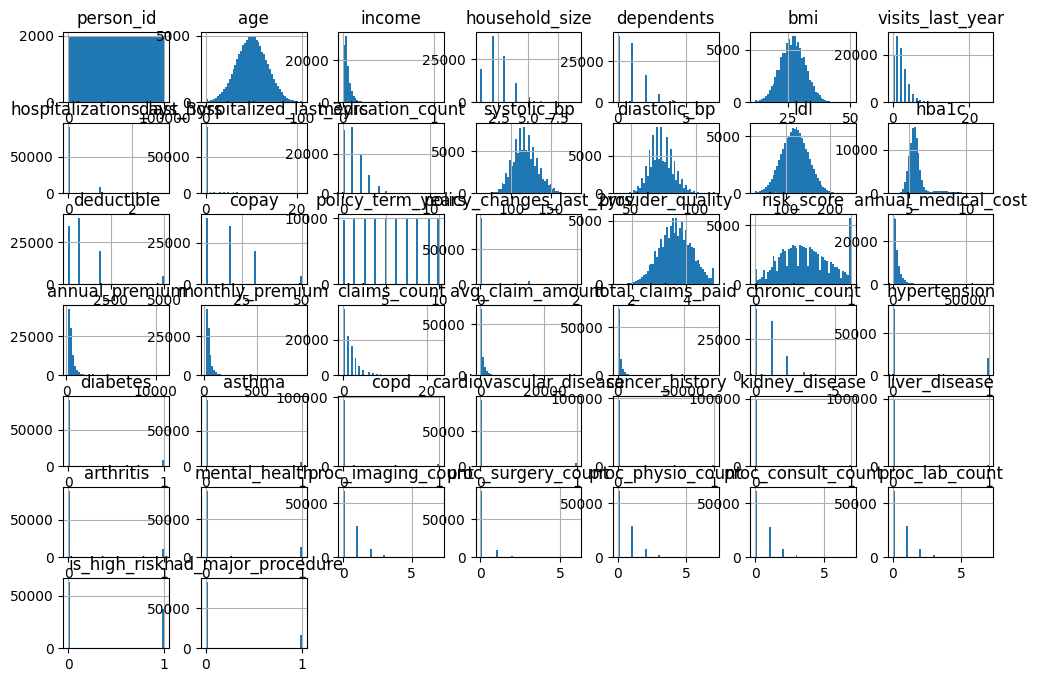

In [50]:
import matplotlib.pyplot as plt

plt.style.use("default")

medical.hist(bins=50, figsize=(12,8))
plt.show()

# 2. 创建测试集

## 方式1：根据datasets长度做索引打乱进行一次性划分
采用np.random.permutation()

In [51]:
import numpy as np

np.random.seed(42)

# 构建打乱与切分数据的函数
def shuffle_and_split_data(data, test_ratio):

    assert 0 < test_ratio < 1

    shuffled_indices = np.random.permutation(len(data)) # 生成0~n-1的随机排列数组
    test_set_size = int(len(data) * test_ratio)

    test_indices = shuffled_indices[:test_set_size] # 取前test_set_size个索引
    train_indices = shuffled_indices[test_set_size:] # 取剩余的索引

    return data.iloc[train_indices], data.iloc[test_indices]

In [52]:
# 使用shuffle_and_split_data函数
train_set, test_set = shuffle_and_split_data(data=medical, test_ratio=0.2)

print("Train set size: ", len(train_set))
print("Test set size: ", len(test_set))

Train set size:  80000
Test set size:  20000


In [53]:
# 查看训练集
train_set.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
75220,72823,73,Female,West,Rural,67700.0,Bachelors,Married,Employed,2,...,0,0,0,1,0,1,0,1,1,0
48955,45561,43,Female,East,Urban,90200.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,2,0,0
44966,27616,70,Male,North,Rural,64200.0,HS,Married,Employed,2,...,0,0,0,2,0,0,0,0,1,0
13568,5174,32,Female,North,Urban,26000.0,Bachelors,Married,Retired,2,...,0,0,0,0,0,1,0,0,0,0
92727,18101,33,Male,South,Urban,32100.0,Bachelors,Married,Retired,3,...,0,0,0,1,0,0,0,1,0,0


## 方式2：采用crc32方式计算hash值以划分数据集

In [54]:
from zlib import crc32

# 判断id是否进入测试集
def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

# 用哈希规则划分数据集
def split_data_with_id_hash(data, test_ratio, id_column):

    ids = data[id_column]
    print("type_ids" + str(type(ids)))
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))

    return data.loc[~in_test_set], data.loc[in_test_set]

In [55]:
train_set, test_set = split_data_with_id_hash(data=medical, test_ratio=0.2, id_column="person_id")
print("Train set size: ", len(train_set))
print("Test set size: ", len(test_set))

type_ids<class 'pandas.core.series.Series'>
Train set size:  80000
Test set size:  20000


In [56]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    80000 non-null  int64  
 1   age                          80000 non-null  int64  
 2   sex                          80000 non-null  object 
 3   region                       80000 non-null  object 
 4   urban_rural                  80000 non-null  object 
 5   income                       80000 non-null  float64
 6   education                    80000 non-null  object 
 7   marital_status               80000 non-null  object 
 8   employment_status            80000 non-null  object 
 9   household_size               80000 non-null  int64  
 10  dependents                   80000 non-null  int64  
 11  bmi                          80000 non-null  float64
 12  smoker                       80000 non-null  object 
 13  alcohol_freq         

In [57]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 1 to 99995
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    20000 non-null  int64  
 1   age                          20000 non-null  int64  
 2   sex                          20000 non-null  object 
 3   region                       20000 non-null  object 
 4   urban_rural                  20000 non-null  object 
 5   income                       20000 non-null  float64
 6   education                    20000 non-null  object 
 7   marital_status               20000 non-null  object 
 8   employment_status            20000 non-null  object 
 9   household_size               20000 non-null  int64  
 10  dependents                   20000 non-null  int64  
 11  bmi                          20000 non-null  float64
 12  smoker                       20000 non-null  object 
 13  alcohol_freq         

## 方式3：利用数据特性构建id再构建hash值以划分数据集
* 未看清数据特性，故暂不写

## 方式4：利用`train_test_split()`函数

In [58]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(medical, test_size=0.2, random_state=42)

In [59]:
len(train_set)

80000

## 方式5：利用`model_selection`包的拆分函数

如StratifiedShuffleSplit()函数（分层混乱拆分器）

In [60]:
medical[["income"]].describe()

,income
count,1.000000e+05
mean,4.987390e+04
std,4.680021e+04
min,1.100000e+03
25%,2.110000e+04
50%,3.620000e+04
75%,6.220000e+04
max,1.061800e+06


In [61]:
medical[["income"]]

,income
0,22700.0
1,12800.0
2,40700.0
3,15600.0
4,89600.0
...,...
99995,127200.0
99996,21600.0
99997,81900.0
99998,43400.0


income_cat
1    25027
2    24982
3    25016
4    23385
5     1590
Name: count, dtype: int64


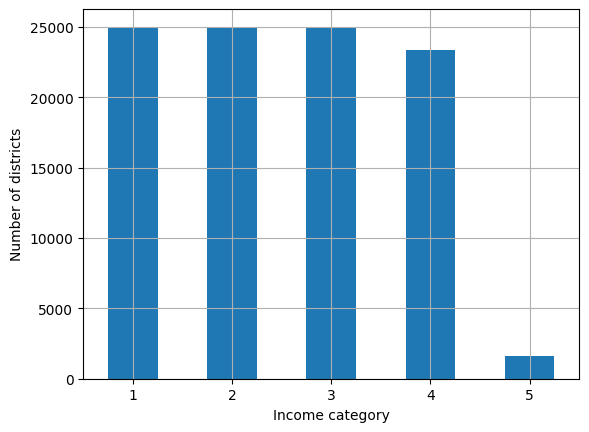

In [62]:
# 使用pd.cut()函数创建一个收入类别属性
medical["income_cat"] = pd.cut(medical["income"],
                               bins=[0, 21100, 36200, 62200, 200000, np.inf],
                               labels=[1, 2, 3, 4, 5])
print(medical["income_cat"].value_counts().sort_index())

medical["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [63]:
medical.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,income_cat
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,1,0,1,0,2,0,1,0,0,2
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,1,1,0,0,1,0,1,1,0,1
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,1,1,0,2,1,0,1,0,3
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,1,0,0,1,0,0,0,1
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,1,0,2,0,1,1,0,1,0,4


In [64]:
# 使用StratifiedShuffleSplit()切分10次
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# 保存每次切分得到的[训练集DataFrame，测试集DataFrame]
strat_splits = []
for train_index, test_index in splitter.split(medical, medical["income_cat"]):
    strat_train_set_n = medical.iloc[train_index]
    strat_test_set_n = medical.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

print(strat_splits[0])

[       person_id  age     sex   region urban_rural    income     education  \
13080       6405   56  Female     East       Urban   30500.0       Masters   
58486      88829   45  Female     East       Urban   36800.0     Bachelors   
27710      27444   48  Female     West       Urban   22100.0  Some College   
35222      51777   31    Male     East    Suburban   24700.0  Some College   
92616        535   37  Female    North    Suburban   19000.0     Bachelors   
...          ...  ...     ...      ...         ...       ...           ...   
77875      63887   75    Male    South    Suburban   21600.0            HS   
73158      65098   48    Male     East       Urban  121500.0  Some College   
26688      86166   45    Male    South       Urban   55700.0     Bachelors   
21526      27978   35  Female     East       Urban  101100.0     Bachelors   
76560      47673   45  Female  Central       Urban   13300.0  Some College   

      marital_status employment_status  household_size  ...  a

In [65]:
# 使用第一次拆分结果
strat_train_set, strat_test_set = strat_splits[0]

print(strat_test_set.info())

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 21131 to 53098
Data columns (total 55 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   person_id                    20000 non-null  int64   
 1   age                          20000 non-null  int64   
 2   sex                          20000 non-null  object  
 3   region                       20000 non-null  object  
 4   urban_rural                  20000 non-null  object  
 5   income                       20000 non-null  float64 
 6   education                    20000 non-null  object  
 7   marital_status               20000 non-null  object  
 8   employment_status            20000 non-null  object  
 9   household_size               20000 non-null  int64   
 10  dependents                   20000 non-null  int64   
 11  bmi                          20000 non-null  float64 
 12  smoker                       20000 non-null  object  
 13  al

In [66]:
# 拆分完数据集后删除income_cat列
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

print(strat_train_set.info())

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 13080 to 76560
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    80000 non-null  int64  
 1   age                          80000 non-null  int64  
 2   sex                          80000 non-null  object 
 3   region                       80000 non-null  object 
 4   urban_rural                  80000 non-null  object 
 5   income                       80000 non-null  float64
 6   education                    80000 non-null  object 
 7   marital_status               80000 non-null  object 
 8   employment_status            80000 non-null  object 
 9   household_size               80000 non-null  int64  
 10  dependents                   80000 non-null  int64  
 11  bmi                          80000 non-null  float64
 12  smoker                       80000 non-null  object 
 13  alcohol_freq     

C:\Users\www12\AppData\Local\Temp\ipykernel_46440\3370433548.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat", axis=1, inplace=True)
C:\Users\www12\AppData\Local\Temp\ipykernel_46440\3370433548.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat", axis=1, inplace=True)


In [68]:
medical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 55 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   person_id                    100000 non-null  int64   
 1   age                          100000 non-null  int64   
 2   sex                          100000 non-null  object  
 3   region                       100000 non-null  object  
 4   urban_rural                  100000 non-null  object  
 5   income                       100000 non-null  float64 
 6   education                    100000 non-null  object  
 7   marital_status               100000 non-null  object  
 8   employment_status            100000 non-null  object  
 9   household_size               100000 non-null  int64   
 10  dependents                   100000 non-null  int64   
 11  bmi                          100000 non-null  float64 
 12  smoker                       100000 non-null 

## 3. 探索和可视化数据

In [70]:
# 备份训练集
medical = strat_train_set.copy()
print(medical.head)

<bound method NDFrame.head of        person_id  age     sex   region urban_rural    income     education  \
13080       6405   56  Female     East       Urban   30500.0       Masters   
58486      88829   45  Female     East       Urban   36800.0     Bachelors   
27710      27444   48  Female     West       Urban   22100.0  Some College   
35222      51777   31    Male     East    Suburban   24700.0  Some College   
92616        535   37  Female    North    Suburban   19000.0     Bachelors   
...          ...  ...     ...      ...         ...       ...           ...   
77875      63887   75    Male    South    Suburban   21600.0            HS   
73158      65098   48    Male     East       Urban  121500.0  Some College   
26688      86166   45    Male    South       Urban   55700.0     Bachelors   
21526      27978   35  Female     East       Urban  101100.0     Bachelors   
76560      47673   45  Female  Central       Urban   13300.0  Some College   

      marital_status employment_s

## 3.1. 可视化数据

目前不好定义横纵轴，不好绘制

## 3.2. 寻找相关性

### 方法1：采用皮尔逊r（`corr()`）方法计算每对属性之间的标准相关系数，只能用于数值型特征

In [72]:
corr_matrix = medical.corr(numeric_only=True)

corr_matrix["annual_medical_cost"].sort_values(ascending=False)

annual_medical_cost            1.000000
monthly_premium                0.965312
annual_premium                 0.965312
total_claims_paid              0.740902
avg_claim_amount               0.632468
risk_score                     0.307315
chronic_count                  0.298019
is_high_risk                   0.252611
days_hospitalized_last_3yrs    0.234166
hospitalizations_last_3yrs     0.210675
visits_last_year               0.196242
claims_count                   0.181666
hypertension                   0.154248
had_major_procedure            0.148908
systolic_bp                    0.145534
age                            0.131615
mental_health                  0.124185
diastolic_bp                   0.119831
arthritis                      0.119593
medication_count               0.116422
diabetes                       0.108240
hba1c                          0.085315
cardiovascular_disease         0.081166
asthma                         0.080049
proc_surgery_count             0.078355


### 方式2：采用Pandas的`scatter_martrix()`函数，将每个数值属性与其他每个数值属性对比

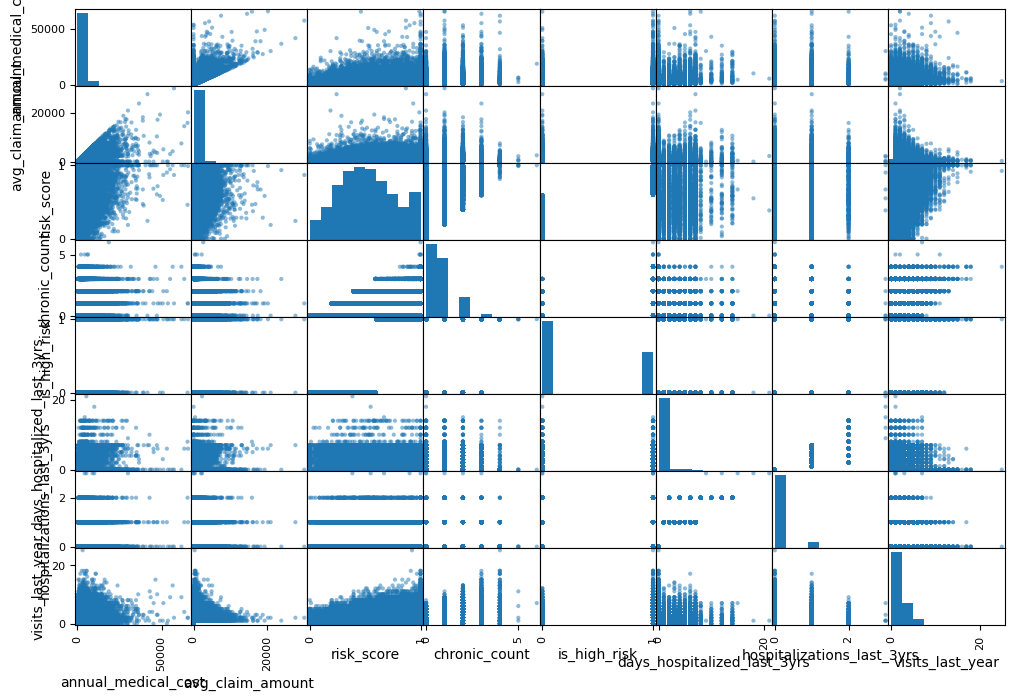

In [79]:
from pandas.plotting import scatter_matrix

scatter_matrix(medical[["annual_medical_cost", "avg_claim_amount", "risk_score", "chronic_count", "is_high_risk", "days_hospitalized_last_3yrs", "hospitalizations_last_3yrs", "visits_last_year"]], figsize=(12,8))
plt.show()

<Axes: xlabel='annual_medical_cost', ylabel='avg_claim_amount'>

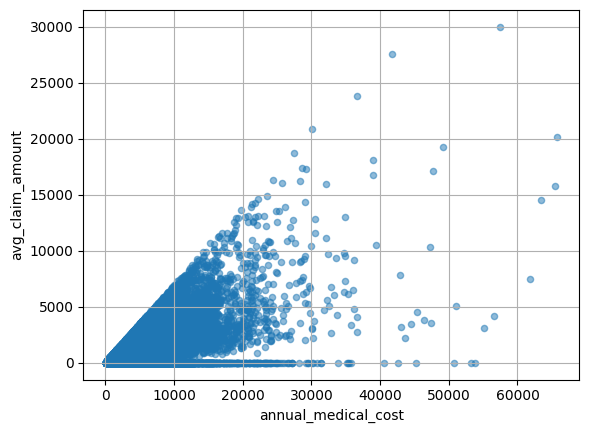

In [80]:
# 看起来avg_claim_amount、risk_score正相关
medical.plot(kind="scatter", x="annual_medical_cost", y = "avg_claim_amount", alpha=0.5, grid=True)

<Axes: xlabel='annual_medical_cost', ylabel='risk_score'>

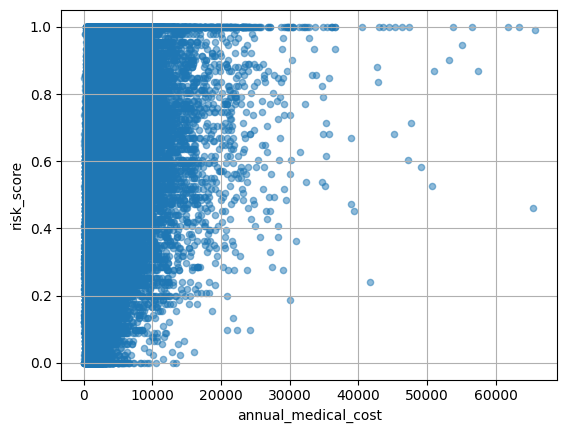

In [81]:
# 看起来avg_claim_amount、risk_score正相关
medical.plot(kind="scatter", x="annual_medical_cost", y = "risk_score", alpha=0.5, grid=True)

## 7.3. 实验不同属性组合
暂未发现不同属性之间关系